# 2. Baselines

In [1]:
from src.models import PersistenceModel, NodeRFModel

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataloading

In [1]:
from src.dataloading import ShallowDataLoader
from src.utils import get_data_env

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 4

shallowdata = ShallowDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
shallowdata.add_time_features()
shallowdata.log_transform_target()
shallowdata.set_splits(split_trainval, split_valtest)
shallowdata.normalize()
shallowdata.add_lagged_features(lags = lags)
shallowdata.finalize()
shallowdata.construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)


KeyError: 'nuts3'

## Persistence Model

In [3]:
persistence = PersistenceModel(shallowdata, name = 'persistence_baseline')
persistence.forecast('test')

PersistenceModel(name='persistence_baseline')

## RF Model

In [4]:
rfmodel = NodeRFModel(shallowdata, name = f'NodeRF leadtime {horizon_leadtime}')
rfmodel.set_global_hparams()
rfmodel.set_model_hparams(n_estimators=100)
rfmodel.train(verbose = 0)
rfmodel.forecast('test')

✓ Initialized 1 RF model
Training RMSE: 0.5600 - Validation RMSE: 0.7521
Training complete!


/home/de-schrijvers/projects/germany_gnn/src/models/shallow/node_rf.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_df.loc[:,'incidence']  = y.values
/home/de-schrijvers/projects/germany_gnn/src/models/shallow/node_rf.py:206: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_df.loc[:,'pred']       = preds


NodeRFModel(name='NodeRF leadtime 3')

## Evaluation

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.12it/s]
/home/de-schrijvers/projects/germany_gnn/src/evaluation/plotter.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/evaluation/plotter.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/evaluation/plotter.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


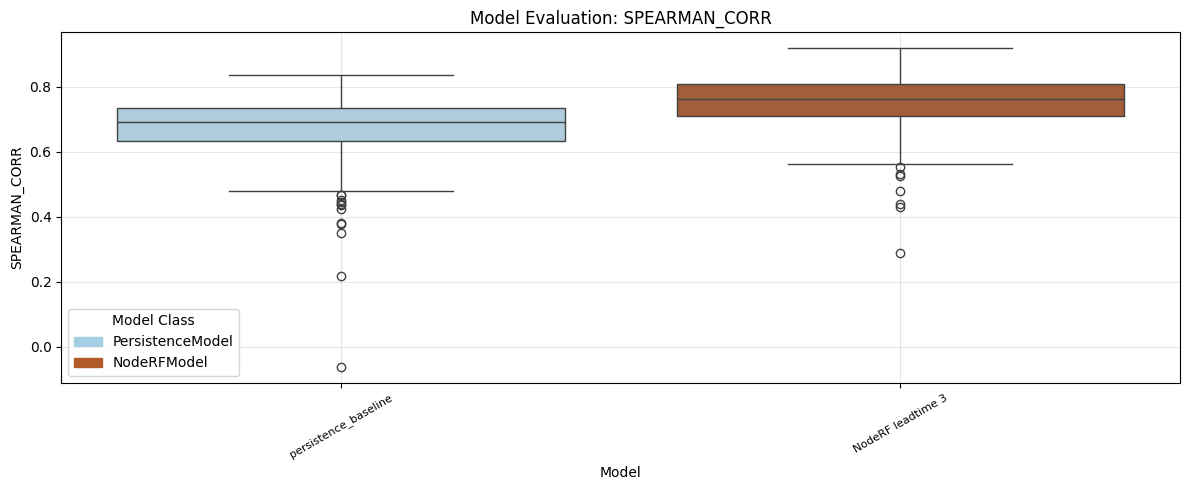

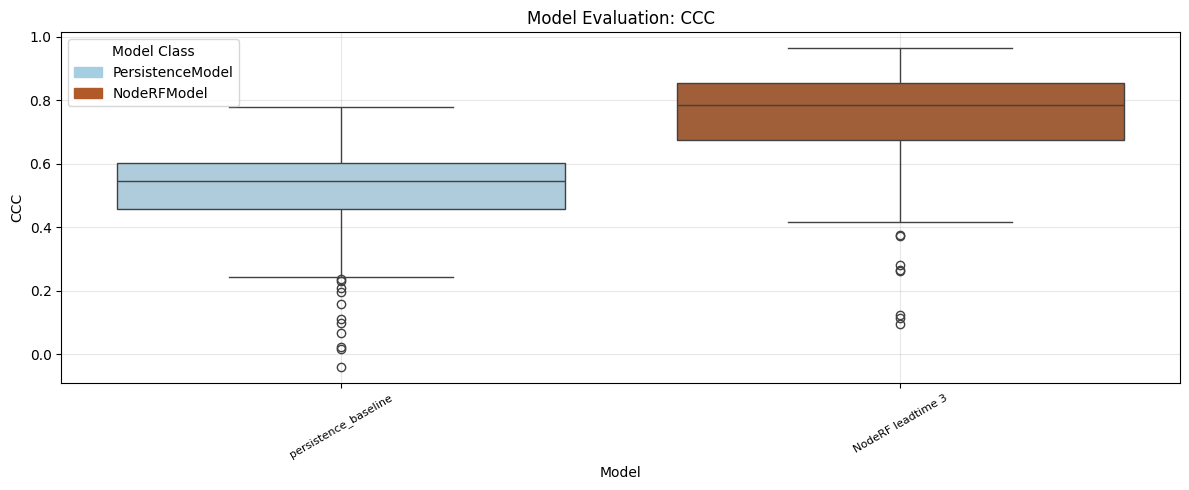

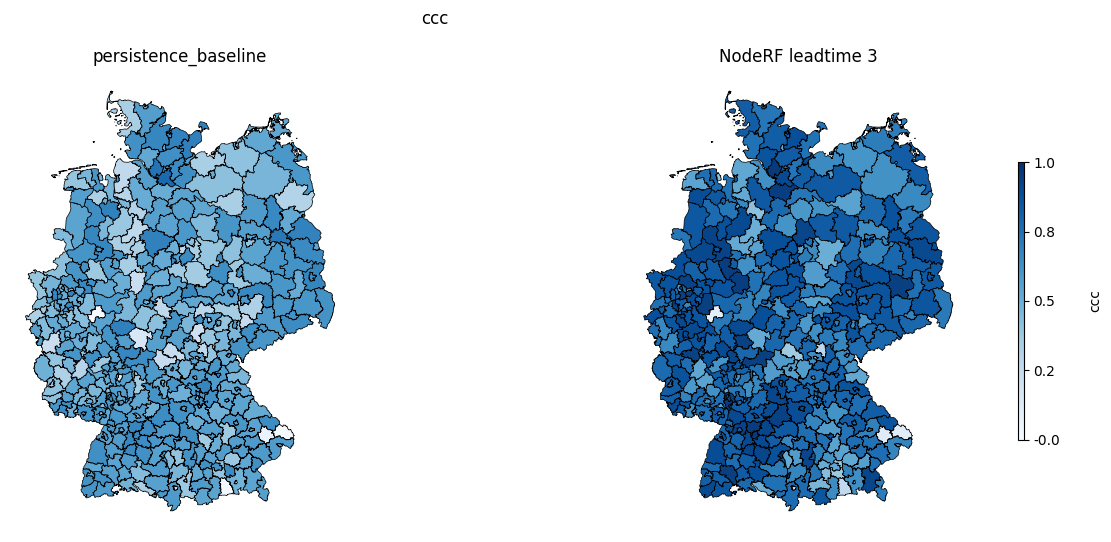

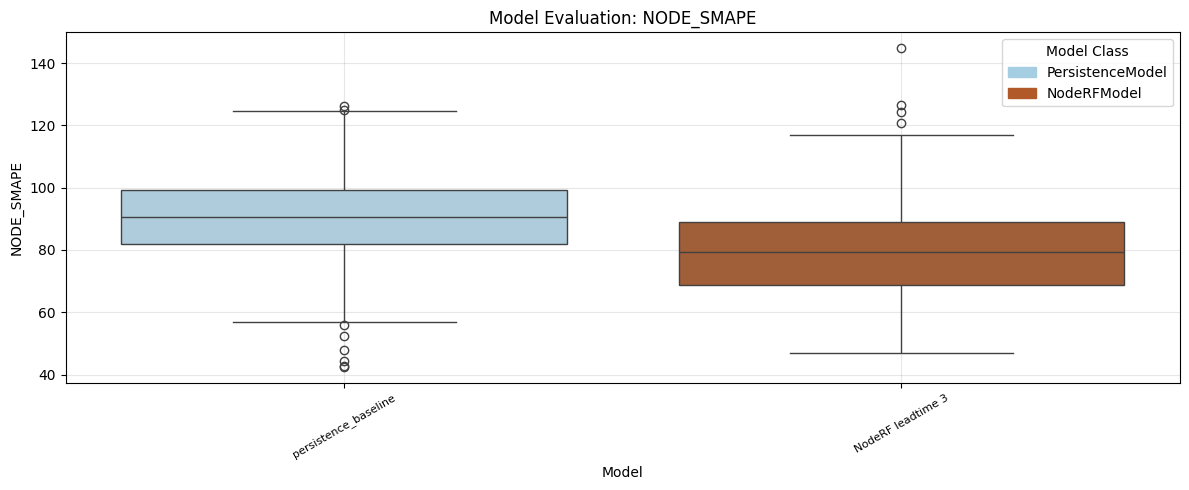

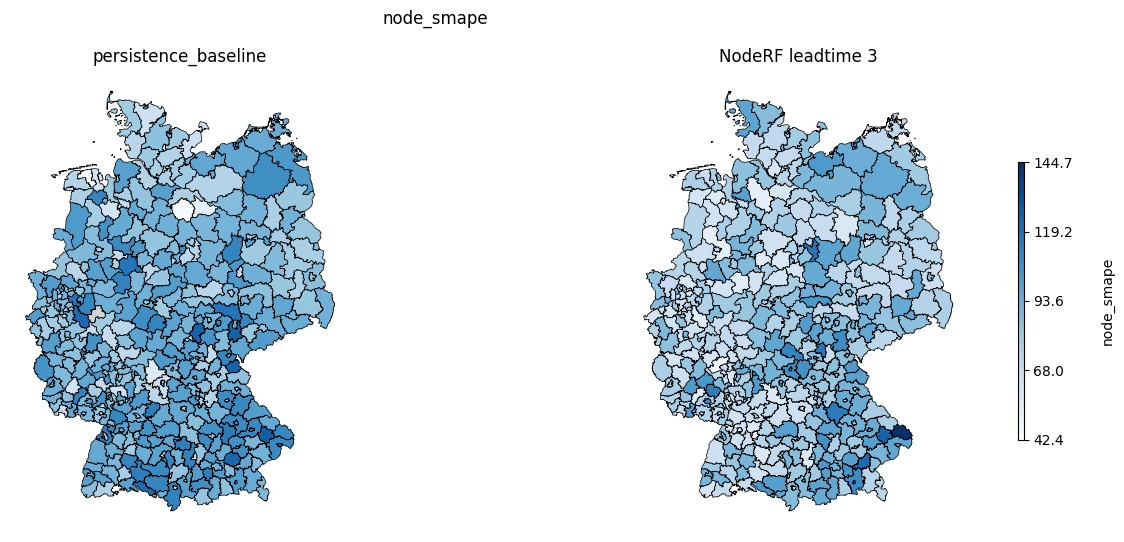

In [5]:
from src.evaluation import Evaluator

evaluation = Evaluator([persistence,rfmodel])
evaluation.add_evaluation()
evaluation.plotter.plot_metric('spearman_corr', plot_type = 'box')
evaluation.plotter.plot_metric('ccc', plot_type = 'box')
evaluation.plotter.plot_metric('ccc', plot_type = 'map')
evaluation.plotter.plot_metric('node_smape', plot_type = 'box')
evaluation.plotter.plot_metric('node_smape', plot_type = 'map')